**Exercise 1**

Support Vector Classifier

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import io

### 93rd congress
uploaded = files.upload()
dat=pd.read_csv("les_93.csv")
dat = dat.dropna()
dat.convert_dtypes()
dat['effective01'] = (dat['les'] > dat['les'].median()).astype(int)
dat_X = np.array(dat[['dwnom1','seniority']])
dat_y = np.array(dat[['effective01']]).flatten()

Saving les_93.csv to les_93.csv


In [2]:
!pip install ISLP
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay
roc_curve = RocCurveDisplay.from_estimator # shorthand
from sklearn.model_selection import train_test_split

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 5.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=ab95bdf522955876365a533de9581d9db318e2270e692b92da4f7fa8caa9c638
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma
  Attempting unins

Best Parameters: {'C': 0.01}
Confusion Matrix:
 [[40  0]
 [ 0 46]]


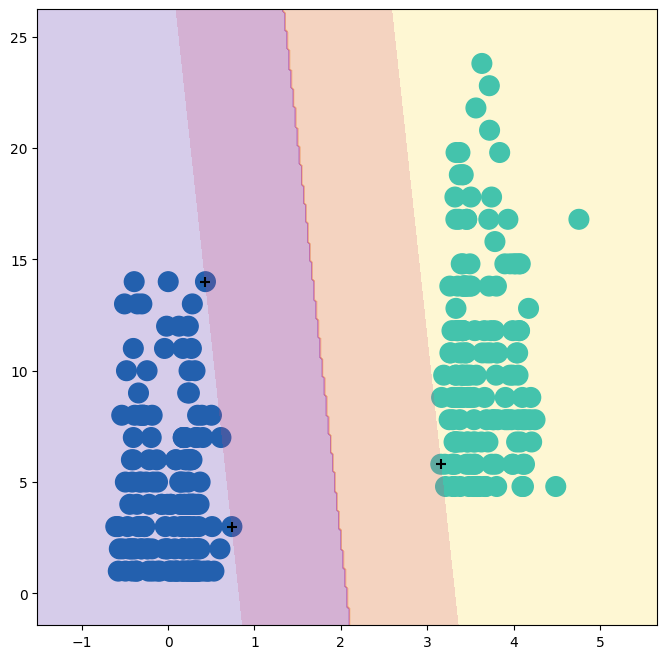

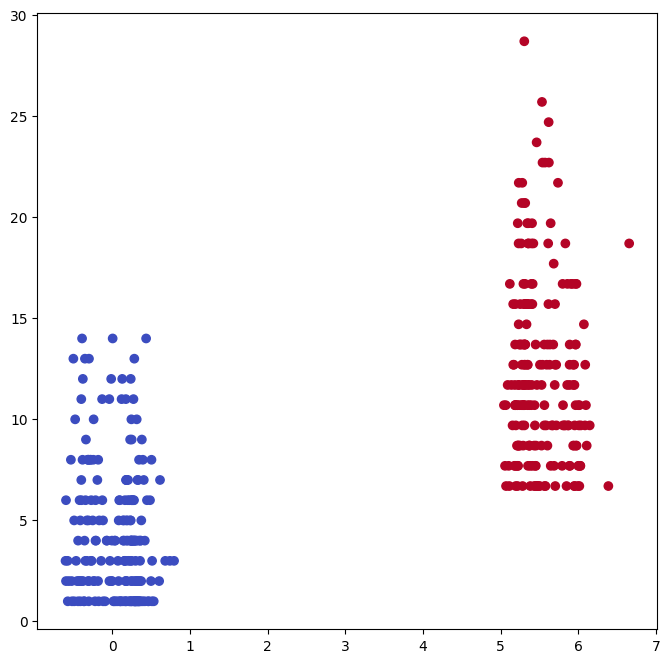

In [13]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(dat_X, dat_y, test_size=0.2, random_state=67)

# Fit classifier
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

# Plot decision boundary
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, svm_linear, ax=ax)

# Grid Search
kfold = KFold(5, random_state=0, shuffle=True)
grid = GridSearchCV(SVC(kernel="linear"),
                    {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]},
                    refit=True,
                    cv=kfold,
                    scoring='accuracy')
grid.fit(X_train, y_train)

# Best model
best_svm = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

# Evaluate on test set
y_test_hat = best_svm.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_hat))

# Augment data
dat_X_augmented = dat_X.copy()
dat_X_augmented[dat_y == 1] += 1.9

# Visualize augmented data
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(dat_X_augmented[:, 0], dat_X_augmented[:, 1], c=dat_y, cmap=plt.cm.coolwarm)

The classifier did not have any errors. Based on the prompt and the fact that only two factors were used, this is likely incorrect.

SVM with Radial Kernel

Best Parameters: {'C': 1, 'gamma': 0.5}
[[105   0]
 [  0 109]]


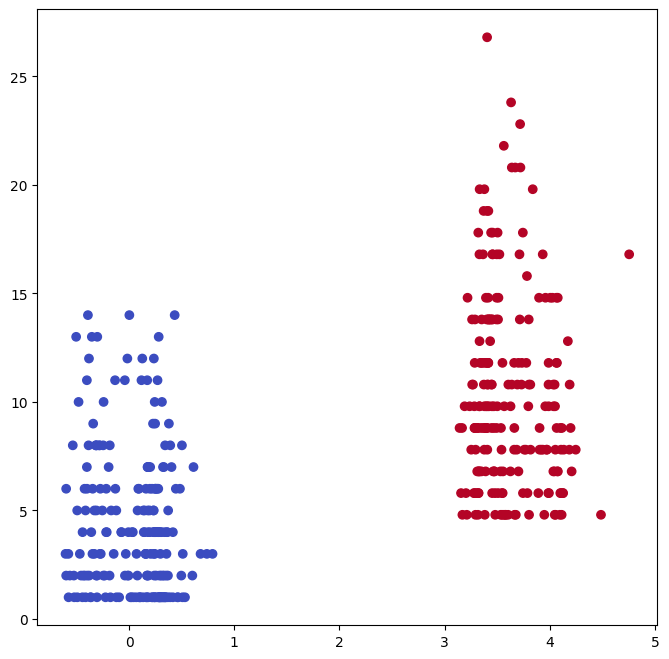

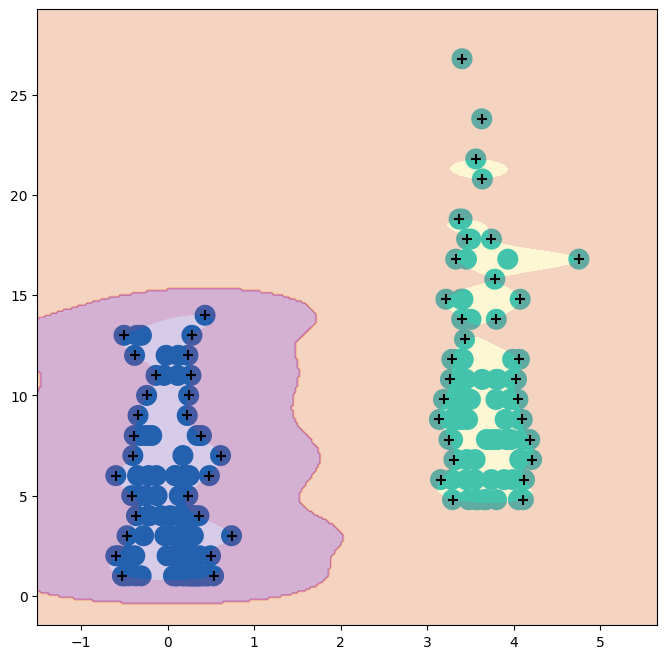

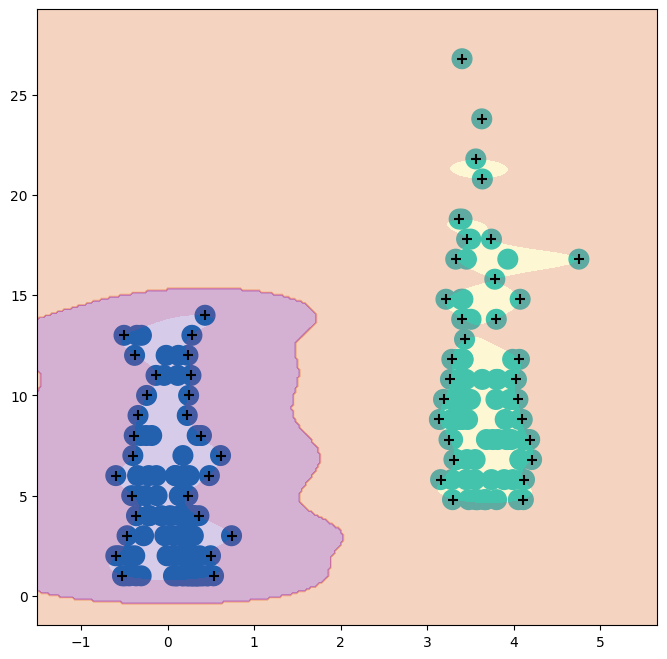

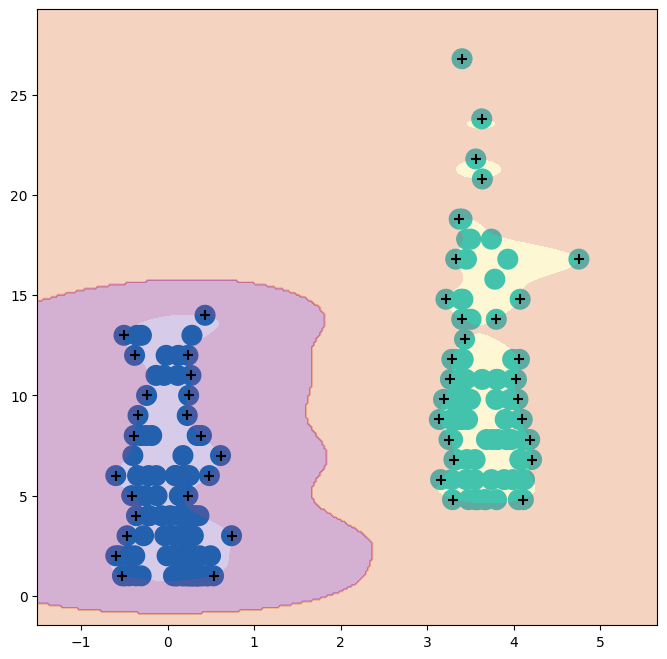

In [11]:
# Plot original data
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(dat_X[:, 0], dat_X[:, 1], c=dat_y, cmap=cm.coolwarm)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(dat_X, dat_y, test_size=0.5, random_state=0)

# Fit using SVC with radial kernel
svm_rbf = SVC(kernel="rbf", gamma=1, C=1)
svm_rbf.fit(X_train, y_train)

# Plot decision boundaries
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, svm_rbf, ax=ax)

# Increase C (C=1e5)
svm_rbf = SVC(kernel="rbf", gamma=1, C=1e5)
svm_rbf.fit(X_train, y_train)

# Plot decision boundaries for higher C
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, svm_rbf, ax=ax)

# Cross-validation and tuning
kfold = KFold(5, random_state=0, shuffle=True)
grid = GridSearchCV(SVC(kernel="rbf"),
                    {'C': [0.1, 1, 10, 100, 1000],
                     'gamma': [0.5, 1, 2, 3, 4]},
                    refit=True,
                    cv=kfold,
                    scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_svm = grid.best_estimator_

# Plot decision boundaries
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, best_svm, ax=ax)

# Evaluate on test data
y_hat_test = best_svm.predict(X_test)
print(confusion_matrix(y_test, y_hat_test))

Per the confusion matrix, the classifier had no errors. Based on the prompt and the fact that only two factors were used, this is likely incorrect.

SVM with Polynomial Kernel

{'C': 0.1, 'degree': 2}
[[40  0]
 [ 0 46]]


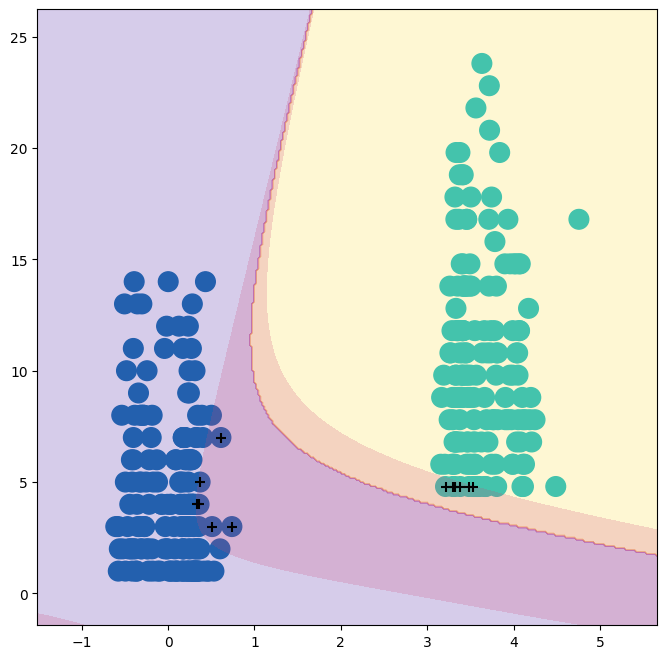

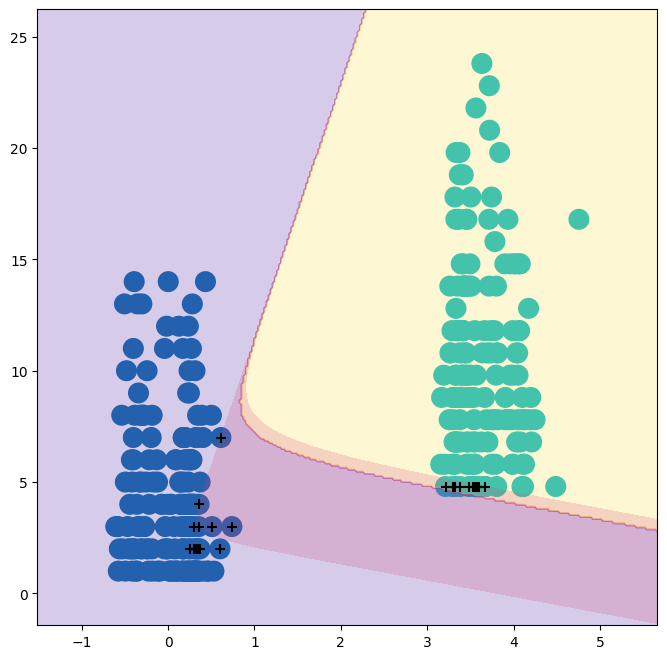

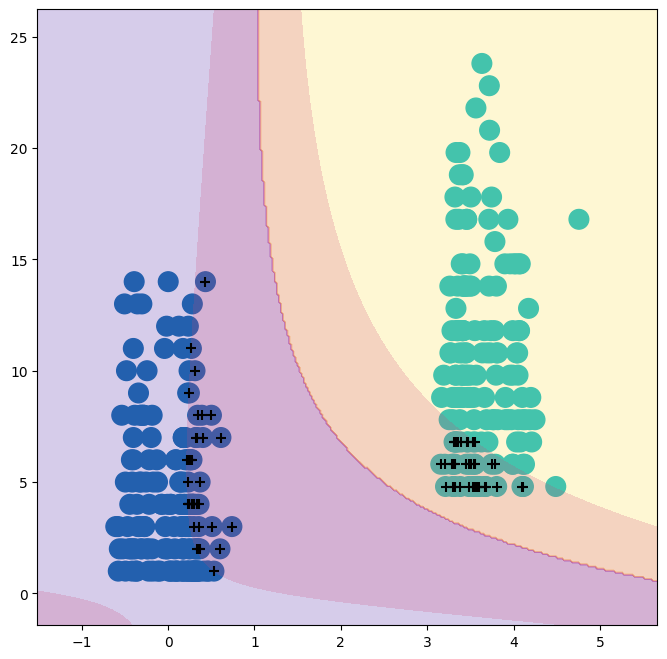

In [15]:
# Fit using SVC with a polynomial kernel (degree=4)
svm_poly = SVC(kernel="poly", degree=4)
svm_poly.fit(X_train, y_train)

# Plot decision boundaries (degree=4)
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, svm_poly, ax=ax)

# Fit using SVC with a polynomial kernel (degree=10)
svm_poly = SVC(kernel="poly", degree=10)
svm_poly.fit(X_train, y_train)

# Plot decision boundaries (degree=10)
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, svm_poly, ax=ax)

# Cross-validation and tuning
kfold = KFold(5, random_state=0, shuffle=True)
grid = GridSearchCV(SVC(kernel="poly"),
                    {'C': [0.1, 1, 10, 100, 1000],
                     'degree': [2, 3, 4, 5, 6]},
                    refit=True,
                    cv=kfold,
                    scoring='accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)

best_svm = grid.best_estimator_

# Plot decision boundaries
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train, y_train, best_svm, ax=ax)

# Evaluate the best model on the test data
y_hat_test = best_svm.predict(X_test)
print(confusion_matrix(y_test, y_hat_test))

Per the confusion matrix, the classifier had no errors. Based on the prompt and the fact that only two factors were used, this is likely incorrect.

**Exercise 2**

A higher number of clusters can improve within-cluster homogeneity, as cases are grouped into smaller clusters, leading to tighter similarity within each cluster. However, this can make it harder to interpret and learn meaningful insights about each cluster because they may become too fragmented or overly specific. Conversely, a lower number of clusters simplifies interpretation, as broader patterns and themes are easier to figure out, but it risks reducing within-cluster homogeneity by grouping more diverse cases together. Striking the right balance depends on the specific use case and the desired granularity of insights. Too high or low numbers of clusters can undermine the utility of the clustering results.

**Exercise 3**

In the study "Do two parties represent the US? Clustering analysis of US public ideology survey," authors Louisa Lee, Siyu Zhang, and Vicky Chuqiao Yang explore whether the two major U.S. political parties adequately represent the public's ideological spectrum and assess if a multiparty system would better capture public opinion. Utilizing data from the American National Election Studies (ANES) Time Series, the researchers analyzed responses from a substantial sample of U.S. citizens, focusing on various political attitudes and demographic factors. The unit of observation was individual survey respondents.

Employing a Gaussian Mixture Model for unsupervised clustering, the authors identified distinct ideological groupings within the population. Their analysis showed a large centrist cluster and a smaller right-wing cluster, with the Democratic Party's position aligning closely with the centrist group, while the Republican Party's stance was situated between the two clusters. The study found that models with more than two clusters provided a better fit for the data, suggesting that a multiparty system could more accurately represent the varied ideological landscape of the U.S. public. These findings are significant as they challenge the binary structure of the current political system and imply that additional parties might better capture the full range of public opinion. However, a critique of the study is its reliance on self-reported data, which may be subject to social desirability bias, potentially affecting the accuracy of the identified ideological clusters and the conclusions drawn about party representation.

Lee, L., Zhang, S., & Yang, V.C. (2017). Do two parties represent the US? Clustering analysis of US public ideology survey. ArXiv, abs/1710.09347.